# Task 1: NAV Trend Analysis
Daily NAV trends of 40 mutual fund schemes (2022–2025)

In [6]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

print(nav.head())
print(nav.columns.tolist())
print(nav.shape)



   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
['amfi_code', 'date', 'nav']
(46000, 3)


In [7]:
nav["date"] = pd.to_datetime(nav["date"])

print(nav["amfi_code"].nunique())

fund_119551 = nav[nav["amfi_code"] == 119551]
print(fund_119551.head())

40
   amfi_code       date      nav
0     119551 2022-01-03  54.3856
1     119551 2022-01-04  54.3474
2     119551 2022-01-05  54.6869
3     119551 2022-01-06  55.4550
4     119551 2022-01-07  55.3692


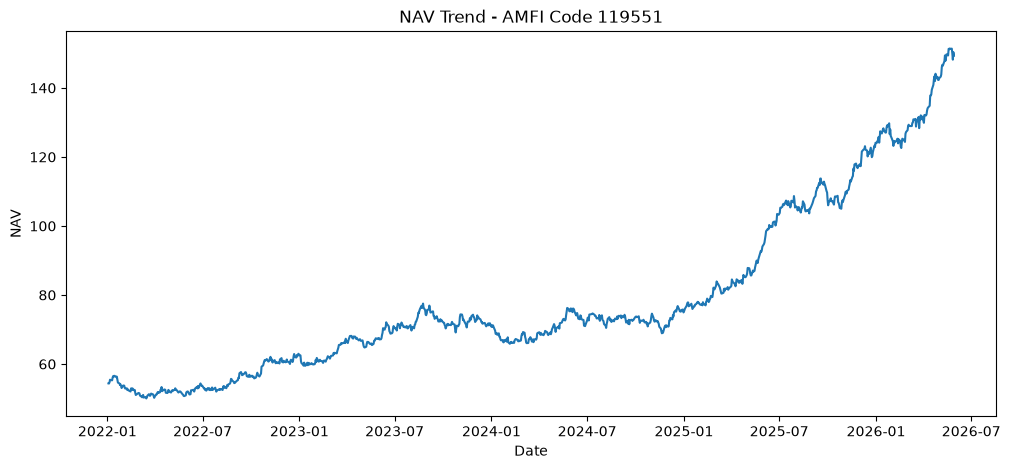

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    fund_119551["date"],
    fund_119551["nav"]
)

plt.title("NAV Trend - AMFI Code 119551")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

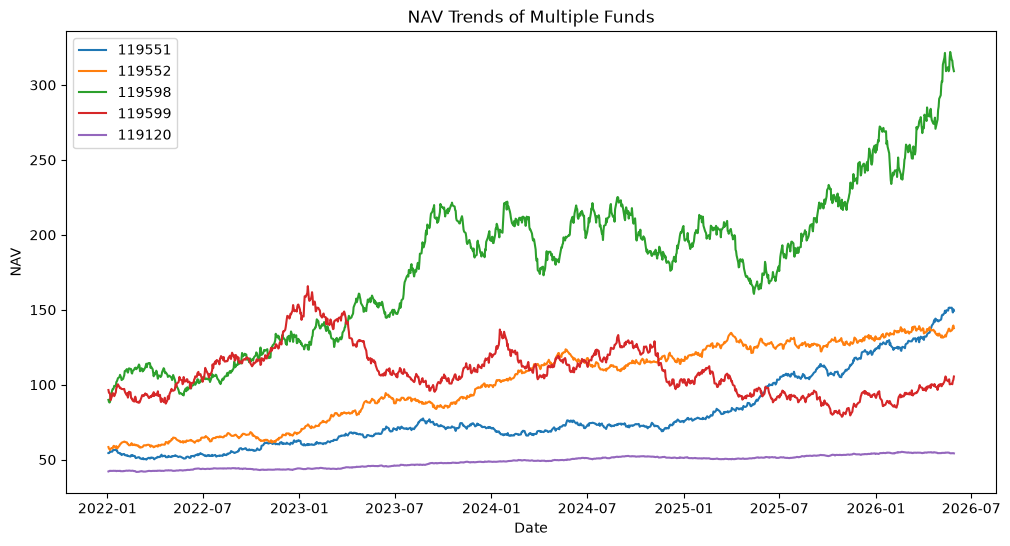

In [9]:
plt.figure(figsize=(12,6))

for code in nav["amfi_code"].unique()[:5]:
    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        label=str(code)
    )

plt.title("NAV Trends of Multiple Funds")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.show()

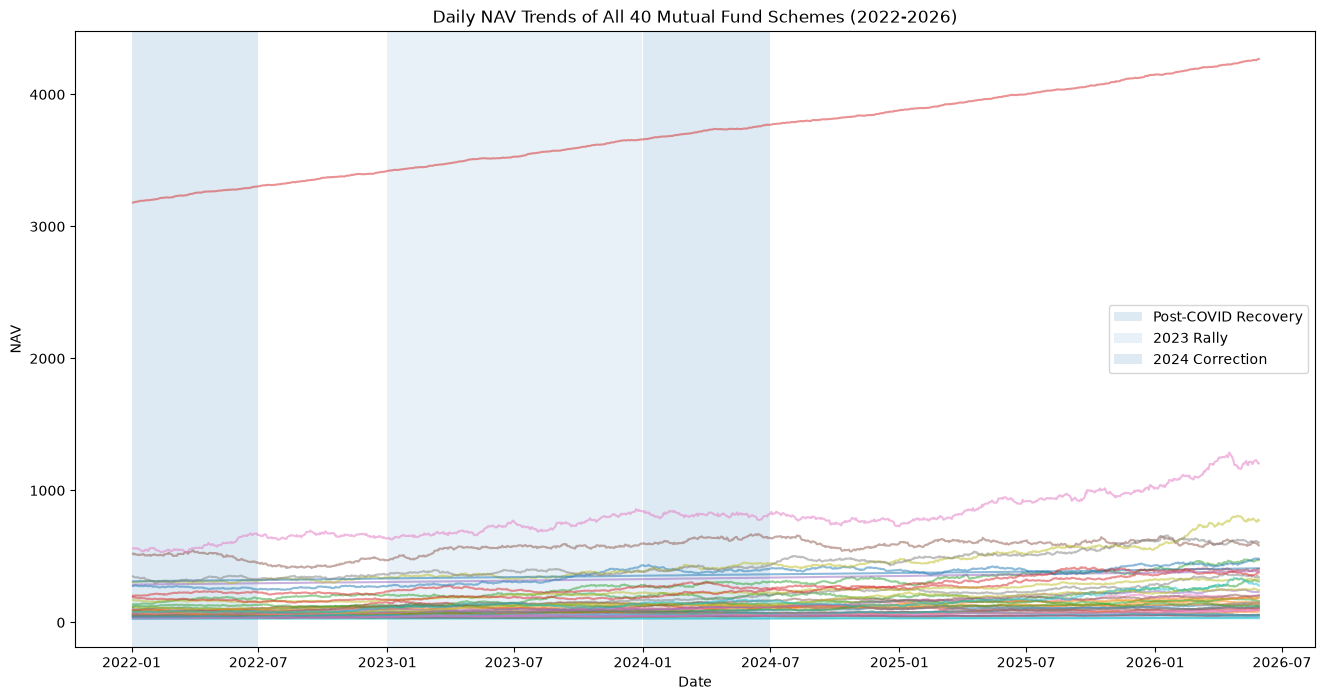

In [10]:
plt.figure(figsize=(16,8))

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code]

    plt.plot(
        fund["date"],
        fund["nav"],
        alpha=0.5
    )

plt.axvspan(
    pd.to_datetime("2022-01-01"),
    pd.to_datetime("2022-06-30"),
    alpha=0.15,
    label="Post-COVID Recovery"
)

plt.axvspan(
    pd.to_datetime("2023-01-01"),
    pd.to_datetime("2023-12-31"),
    alpha=0.10,
    label="2023 Rally"
)

plt.axvspan(
    pd.to_datetime("2024-01-01"),
    pd.to_datetime("2024-06-30"),
    alpha=0.15,
    label="2024 Correction"
)

plt.title("Daily NAV Trends of All 40 Mutual Fund Schemes (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.show()

# Task 2: AUM Growth Analysis
AUM comparison of major fund houses (2022–2025)

In [11]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.head())
print(aum.columns.tolist())
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
print(aum.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
(90, 6)


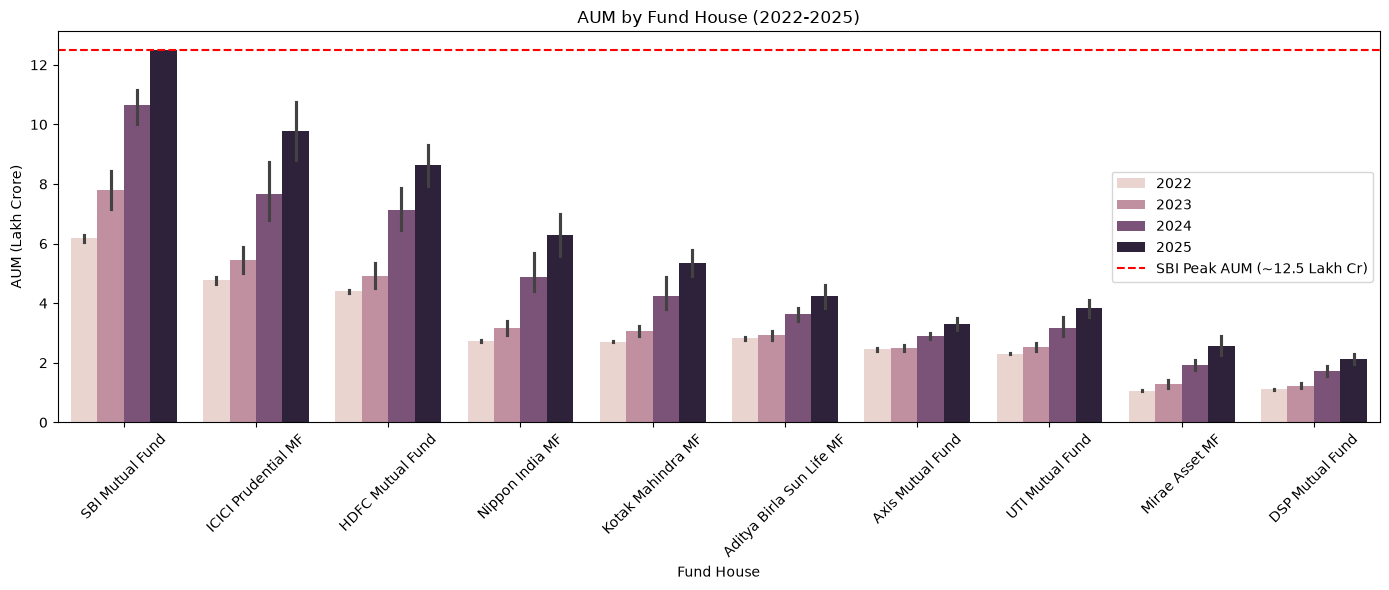

Observation: SBI Mutual Fund remained the largest AMC and crossed approximately 12.5 lakh crore AUM.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title("AUM by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.axhline(
    y=12.5,
    color="red",
    linestyle="--",
    label="SBI Peak AUM (~12.5 Lakh Cr)"
)

plt.legend()

plt.show()

print("Observation: SBI Mutual Fund remained the largest AMC and crossed approximately 12.5 lakh crore AUM.")

In [13]:
latest_date = aum["date"].max()

latest_aum = aum[aum["date"] == latest_date]

latest_aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
83,2025-12-31,Nippon India MF,7.00,700000,177,2025
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168,2025


In [14]:
top10 = latest_aum.sort_values(
    by="aum_crore",
    ascending=False
).head(10)

top10

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025
81,2025-12-31,ICICI Prudential MF,10.74,1074000,216,2025
82,2025-12-31,HDFC Mutual Fund,9.30,930000,195,2025
83,2025-12-31,Nippon India MF,7.00,700000,177,2025
84,2025-12-31,Kotak Mahindra MF,5.80,580000,168,2025
85,2025-12-31,Aditya Birla Sun Life MF,4.60,460000,199,2025
87,2025-12-31,UTI Mutual Fund,4.10,410000,142,2025
86,2025-12-31,Axis Mutual Fund,3.50,350000,95,2025
88,2025-12-31,Mirae Asset MF,2.90,290000,56,2025
89,2025-12-31,DSP Mutual Fund,2.30,230000,88,2025


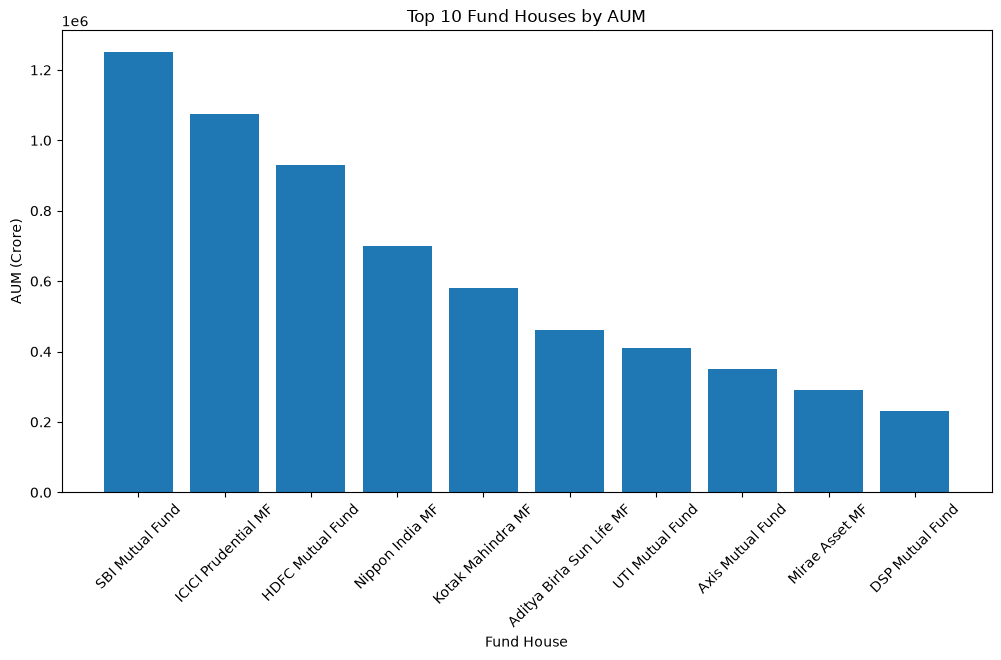

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top10["fund_house"],
    top10["aum_crore"]
)

plt.title("Top 10 Fund Houses by AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")

plt.xticks(rotation=45)

plt.show()

# Task 3: SIP Inflow Trend Analysis
Monthly SIP inflow growth and ₹31,002 Cr milestone


In [16]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns.tolist())
print(sip.shape)

sip["month"] = pd.to_datetime(sip["month"])

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
(48, 6)


In [17]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.show()

In [18]:
sip.loc[sip["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

In [19]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend (2022-2025)",
    markers=True
)

fig.add_annotation(
    x="2025-12-01",
    y=31002,
    text="31,002 Cr Milestone",
    showarrow=True
)

fig.show()

# Task 4: Category-wise Inflow Heatmap
Analysis of net inflows across mutual fund categories

In [20]:
import pandas as pd

cat = pd.read_csv("../data/raw/05_category_inflows.csv")

cat["month"] = pd.to_datetime(cat["month"])

In [21]:
pivot = cat.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

pivot.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


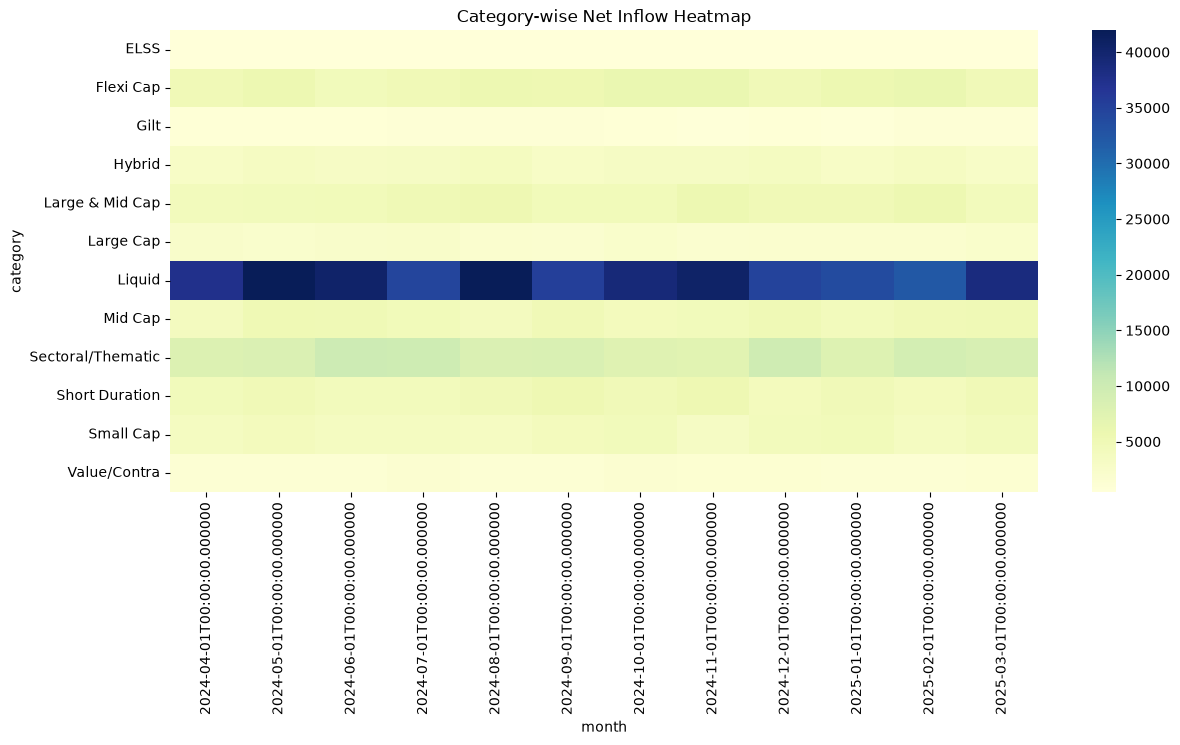

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflow Heatmap")
plt.show()

# Task 5: Investor Demographics Analysis
Age group distribution and SIP investment behavior

In [23]:
inv = pd.read_csv("../data/raw/08_investor_transactions.csv")
age_counts = inv["age_group"].value_counts()

print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


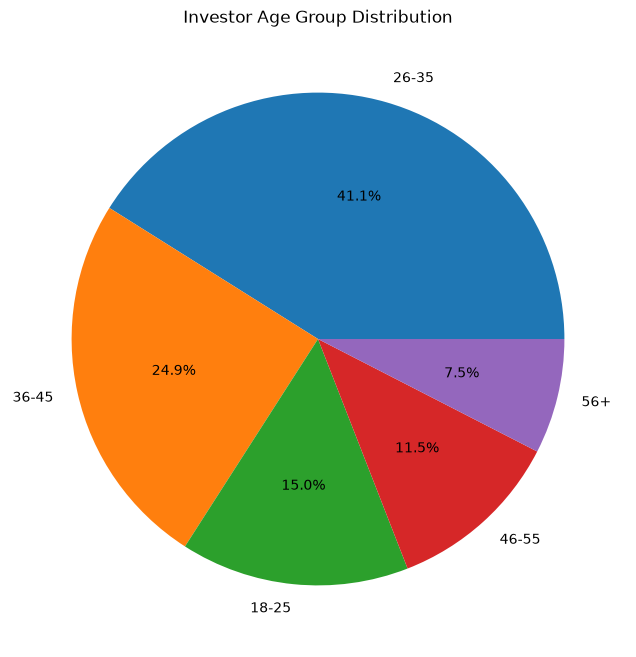

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

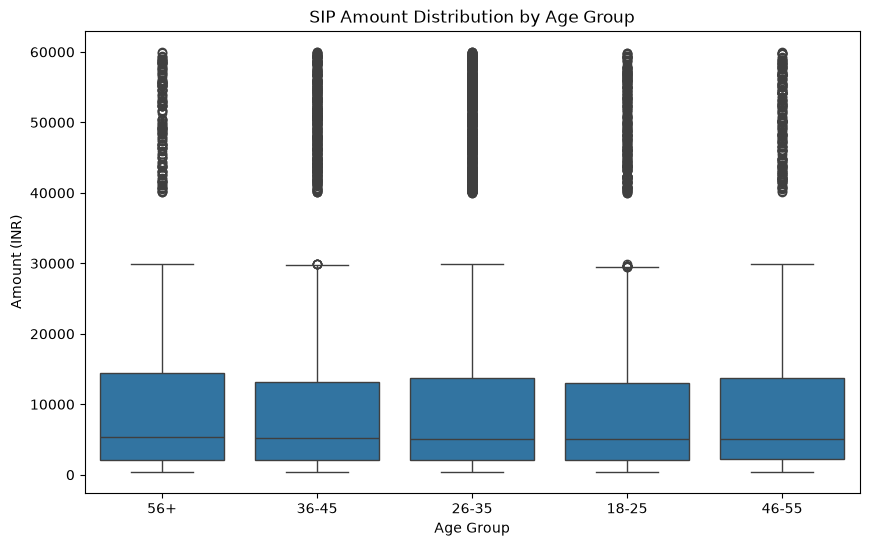

In [25]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

inv = pd.read_csv("../data/raw/08_investor_transactions.csv")
sip_txn = inv[inv["transaction_type"] == "SIP"]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

# Task 6: Geographic Distribution Analysis
State-wise SIP investments and T30 vs B30 participation

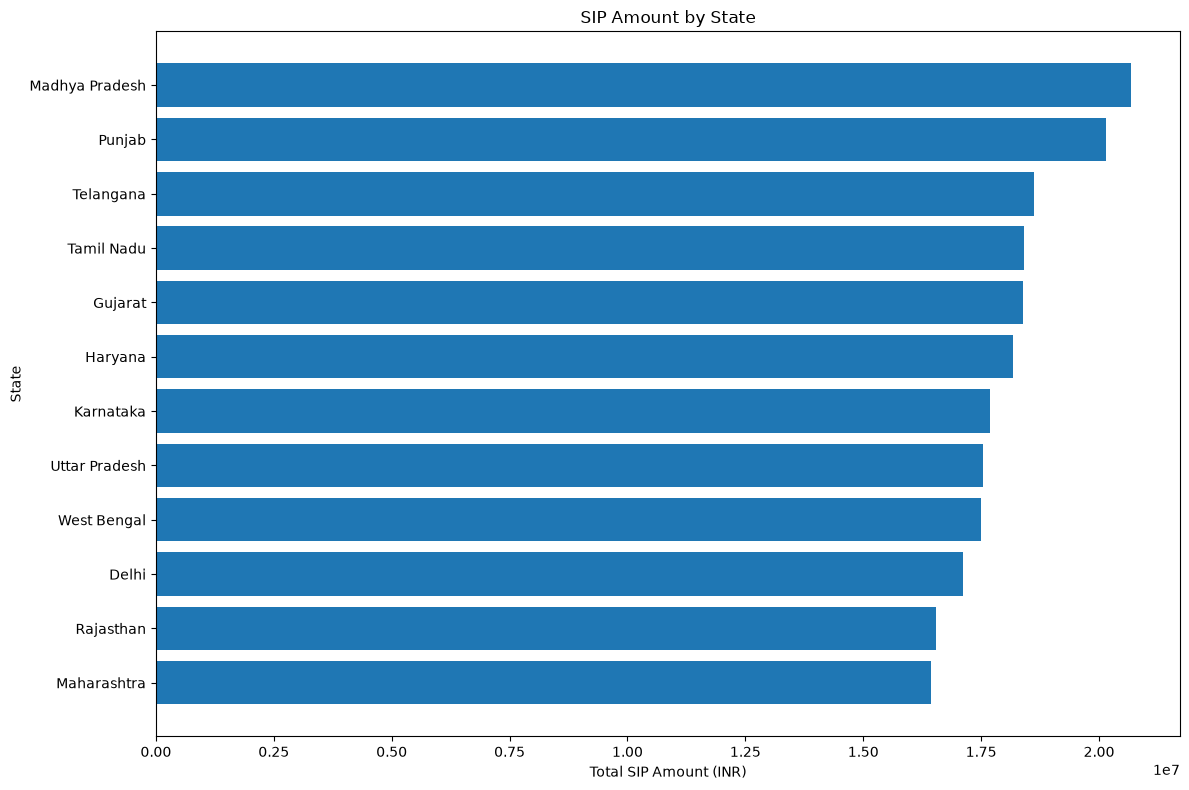

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

inv = pd.read_csv("../data/raw/08_investor_transactions.csv")

sip_data = inv[inv["transaction_type"] == "SIP"]

state_sip = (
    sip_data.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 8))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("SIP Amount by State")
plt.xlabel("Total SIP Amount (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

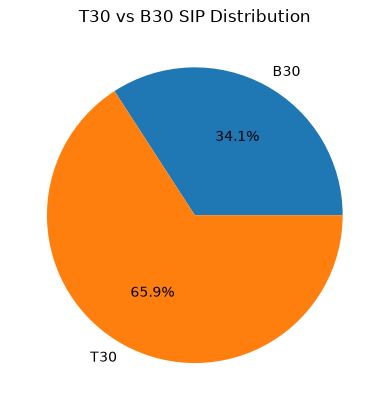

In [27]:
tier_data = inv.groupby("city_tier")["amount_inr"].sum()

plt.pie(
    tier_data,
    labels=tier_data.index,
    autopct='%1.1f%%'
)

plt.title("T30 vs B30 SIP Distribution")
plt.show()

In [28]:
state_counts = inv["state"].value_counts()

print(state_counts.head(10))

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Name: count, dtype: int64


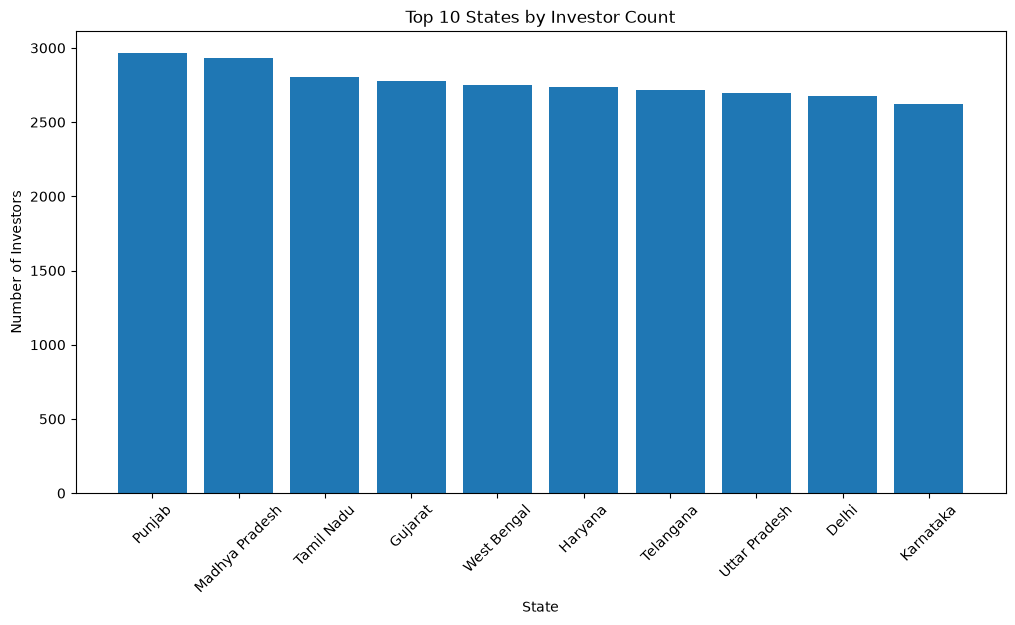

In [29]:
import matplotlib.pyplot as plt

top_states = state_counts.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_states.index,
    top_states.values
)

plt.title("Top 10 States by Investor Count")
plt.xlabel("State")
plt.ylabel("Number of Investors")

plt.xticks(rotation=45)

plt.show()

In [30]:
tier_counts = inv["city_tier"].value_counts()

print(tier_counts)

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


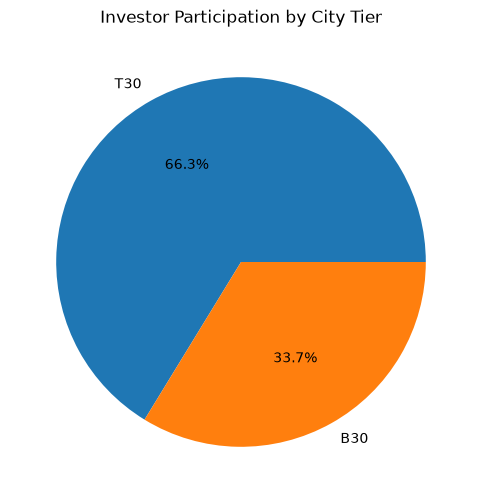

In [31]:
plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("Investor Participation by City Tier")

plt.show()

# Task 7: Folio Growth Analysis # Task 7: Folio Growth Analysis
Growth in mutual fund folios from 2022 to 2025

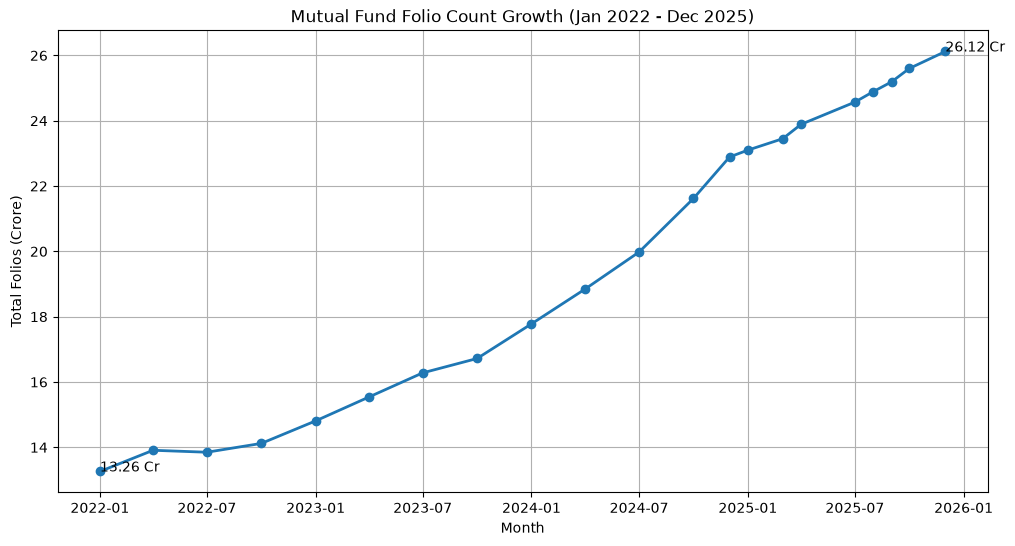

Starting Folios: 13.26
Ending Folios: 26.12


In [32]:
import pandas as pd
import matplotlib.pyplot as plt

folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Mutual Fund Folio Count Growth (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    "13.26 Cr",
    xy=(folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

plt.annotate(
    "26.12 Cr",
    xy=(folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.grid(True)

plt.show()

print("Starting Folios:", folio["total_folios_crore"].iloc[0])
print("Ending Folios:", folio["total_folios_crore"].iloc[-1])

# Task 8: Correlation Matrix Analysis
Correlation of NAV returns across 10 selected funds

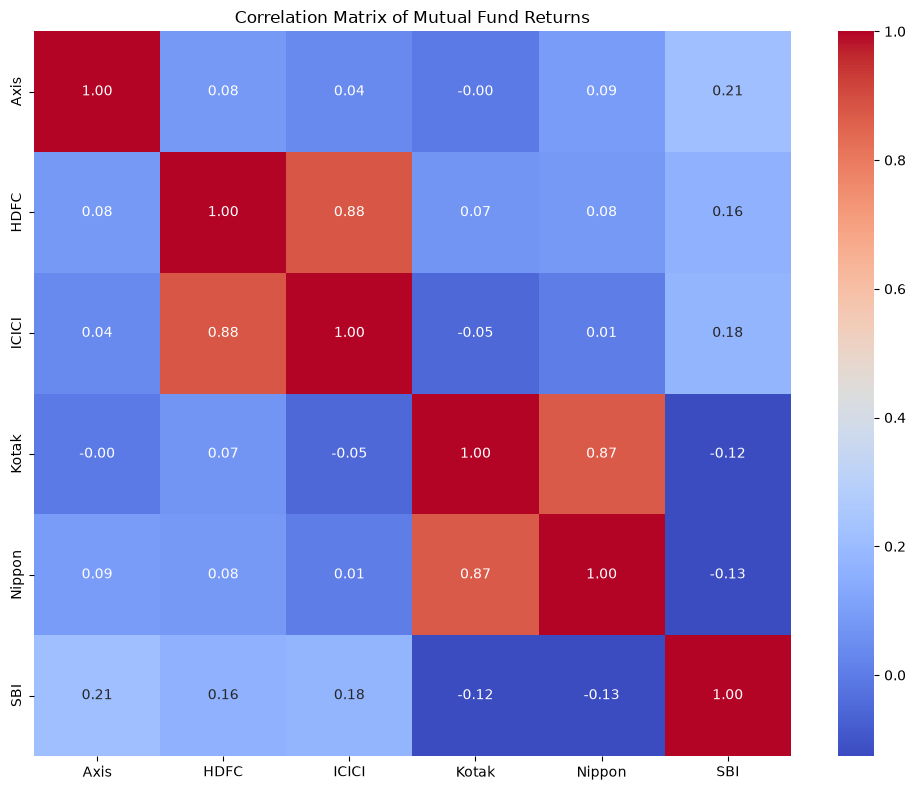

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

axis = pd.read_csv("../data/raw/axis_bluechip_nav.csv")
hdfc = pd.read_csv("../data/raw/hdfc_top100_nav.csv")
icici = pd.read_csv("../data/raw/icici_bluechip_nav.csv")
kotak = pd.read_csv("../data/raw/kotak_bluechip_nav.csv")
nippon = pd.read_csv("../data/raw/nippon_large_cap_nav.csv")
sbi = pd.read_csv("../data/raw/sbi_bluechip_nav.csv")

for df in [axis, hdfc, icici, kotak, nippon, sbi]:
    df["date"] = pd.to_datetime(
    df["date"],
    format="%d-%m-%Y"
)

combined = pd.DataFrame()

combined["date"] = axis["date"]

combined["Axis"] = axis["nav"]
combined["HDFC"] = hdfc["nav"]
combined["ICICI"] = icici["nav"]
combined["Kotak"] = kotak["nav"]
combined["Nippon"] = nippon["nav"]
combined["SBI"] = sbi["nav"]

returns = combined.drop(columns="date").pct_change()

returns = returns.dropna()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Matrix of Mutual Fund Returns"
)

plt.tight_layout()

plt.show()

# Task 9: Sector Allocation Analysis
Sector-wise portfolio allocation and exposure analysis

In [34]:
import pandas as pd

holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
sector_alloc = holdings.groupby(
    "sector"
)["weight_pct"].sum().sort_values(
    ascending=False
)

print(sector_alloc)


sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


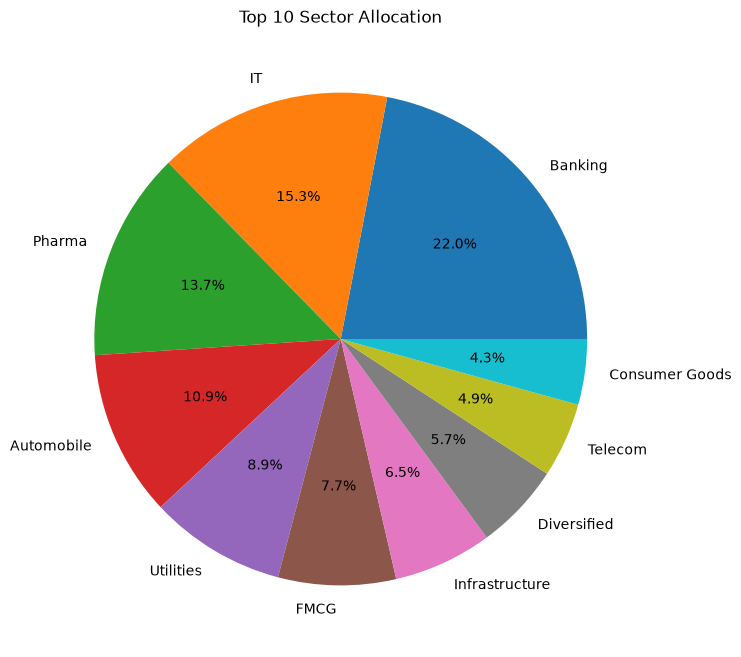

In [35]:
top10 = sector_alloc.head(10)

plt.figure(figsize=(10,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%"
)

plt.title("Top 10 Sector Allocation")

plt.show()

# ==========================================
# DAY 4 - TASK 1
# Daily Returns & Annualized Returns
# ==========================================

In [41]:
import pandas as pd
import numpy as np
import os

# NAV files
files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

results = []

for file in files:

    # Read file
    df = pd.read_csv(f"../data/raw/{file}")

    # Convert date
    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    # Sort oldest to newest
    df = df.sort_values("date")

    # Calculate daily return
    df["daily_return"] = df["nav"].pct_change()

    # Remove abnormal returns (>50% or <-50%)
    df = df[
    (df["daily_return"] < 0.50) &
    (df["daily_return"] > -0.50)
    ]

    annualized_return = (
    (1 + df["daily_return"]).prod()
    ) ** (
    252 / len(df)
    ) - 1

    results.append({
        "fund_name": file.replace("_nav.csv", ""),
        "annualized_return_%":
            round(annualized_return * 100, 2)
    })

# Final report
returns_df = pd.DataFrame(results)

print(returns_df)

# Save output
returns_df.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("\nreturns_computed.csv saved successfully!")

          fund_name  annualized_return_%
0     axis_bluechip                 6.91
1       hdfc_top100                34.76
2    icici_bluechip                16.17
3    kotak_bluechip                17.37
4  nippon_large_cap                15.78
5      sbi_bluechip                 0.22

returns_computed.csv saved successfully!


# ==========================================
# DAY 4 - TASK 2
# CAGR Analysis (1Y, 3Y, 5Y)
# ==========================================

In [46]:
import pandas as pd
import numpy as np

files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

results = []

for file in files:

    df = pd.read_csv(f"../data/raw/{file}")

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    latest_date = df["date"].max()

    fund_name = file.replace("_nav.csv", "")

    row = {"fund_name": fund_name}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        period_df = df[df["date"] >= start_date]

        actual_years = (
         (period_df["date"].max() - period_df["date"].min()).days
        ) / 365

        if actual_years >= years * 0.9:

            start_nav = period_df["nav"].iloc[0]
            end_nav = period_df["nav"].iloc[-1]

            cagr = (
                (end_nav / start_nav) ** (1 / years)
            ) - 1

            row[f"{years}Y_CAGR_%"] = round(
                cagr * 100,
                2
            )

        else:

            row[f"{years}Y_CAGR_%"] = np.nan

    results.append(row)

cagr_df = pd.DataFrame(results)

print(cagr_df)

cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("\ncagr_report.csv saved successfully!")

          fund_name  1Y_CAGR_%  3Y_CAGR_%  5Y_CAGR_%
0     axis_bluechip       6.22       7.36       6.54
1       hdfc_top100        NaN        NaN        NaN
2    icici_bluechip       1.23      10.82       8.32
3    kotak_bluechip       5.45      17.63      18.35
4  nippon_large_cap       1.48      15.03      16.25
5      sbi_bluechip      -1.42      -2.00      -7.36

cagr_report.csv saved successfully!


# ==========================================
# DAY 4 - TASK 3
# Sharpe Ratio Calculation
# ==========================================

In [49]:
import pandas as pd
import numpy as np

files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

rf = 0.065   # 6.5% Risk-Free Rate

results = []

for file in files:

    df = pd.read_csv(f"../data/raw/{file}")

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    df["daily_return"] = df["nav"].pct_change()

    # Remove NaN
    df = df.dropna()

    # Remove infinity values
    df = df[np.isfinite(df["daily_return"])]

    # Remove extreme outliers
    df = df[
    (df["daily_return"] > -0.50) &
    (df["daily_return"] < 0.50)
    ]

    # Annual Return
    annual_return = (
        (1 + df["daily_return"]).prod()
    ) ** (
        252 / len(df)
    ) - 1

    # Annual Volatility
    annual_volatility = (
        df["daily_return"].std()
        * np.sqrt(252)
    )

    # Sharpe Ratio
    sharpe_ratio = (
        annual_return - rf
    ) / annual_volatility

    results.append({
        "fund_name": file.replace("_nav.csv", ""),
        "annual_return_%": round(
            annual_return * 100, 2
        ),
        "annual_volatility_%": round(
            annual_volatility * 100, 2
        ),
        "sharpe_ratio": round(
            sharpe_ratio, 3
        )
    })

sharpe_df = pd.DataFrame(results)

print(sharpe_df)

sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("\nsharpe_values.csv saved successfully!")

          fund_name  annual_return_%  annual_volatility_%  sharpe_ratio
0     axis_bluechip             6.91                 0.54         0.759
1       hdfc_top100            34.76                18.57         1.522
2    icici_bluechip            16.17                15.31         0.632
3    kotak_bluechip            17.37                15.42         0.705
4  nippon_large_cap            15.78                16.69         0.556
5      sbi_bluechip             0.22                 8.70        -0.722

sharpe_values.csv saved successfully!


# ==========================================
# DAY 4 - TASK 4
# Sortino Ratio Calculation
# ==========================================

In [50]:
import pandas as pd
import numpy as np

files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

rf = 0.065

results = []

for file in files:

    df = pd.read_csv(f"../data/raw/{file}")

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    # Daily Returns
    df["daily_return"] = df["nav"].pct_change()

    # Data Cleaning
    df = df.dropna()

    df = df[np.isfinite(df["daily_return"])]

    df = df[
        (df["daily_return"] > -0.50) &
        (df["daily_return"] < 0.50)
    ]

    # Annual Return
    annual_return = (
        (1 + df["daily_return"]).prod()
    ) ** (
        252 / len(df)
    ) - 1

    # Negative Returns Only
    downside_returns = df[
        df["daily_return"] < 0
    ]["daily_return"]

    # Downside Deviation
    downside_deviation = (
        downside_returns.std()
        * np.sqrt(252)
    )

    # Sortino Ratio
    sortino_ratio = (
        annual_return - rf
    ) / downside_deviation

    results.append({
        "fund_name":
        file.replace("_nav.csv", ""),

        "annual_return_%":
        round(annual_return * 100, 2),

        "downside_risk_%":
        round(
            downside_deviation * 100,
            2
        ),

        "sortino_ratio":
        round(
            sortino_ratio,
            3
        )
    })

sortino_df = pd.DataFrame(results)

print(sortino_df)

sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print(
    "\nsortino_values.csv saved successfully!"
)

          fund_name  annual_return_%  downside_risk_%  sortino_ratio
0     axis_bluechip             6.91             1.08          0.380
1       hdfc_top100            34.76            12.45          2.271
2    icici_bluechip            16.17            12.31          0.786
3    kotak_bluechip            17.37            13.25          0.820
4  nippon_large_cap            15.78            13.46          0.690
5      sbi_bluechip             0.22            15.36         -0.409

sortino_values.csv saved successfully!


# ==========================================
# DAY 4 - TASK 5
# Alpha & Beta Analysis
# ==========================================

In [51]:
import pandas as pd

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.head())

print(benchmark.columns)

print(benchmark.shape)

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')
(8050, 3)


In [52]:
import pandas as pd
import numpy as np

# -----------------------------
# Load Benchmark
# -----------------------------

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Use NIFTY50 only
benchmark = benchmark[
    benchmark["index_name"] == "NIFTY50"
]

benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

benchmark = benchmark[
    ["date", "benchmark_return"]
]

# -----------------------------
# Fund Files
# -----------------------------

files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

results = []

for file in files:

    df = pd.read_csv(
        f"../data/raw/{file}"
    )

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    df["fund_return"] = (
        df["nav"].pct_change()
    )

    # Clean data
    df = df.dropna()

    df = df[
        np.isfinite(df["fund_return"])
    ]

    df = df[
        (df["fund_return"] > -0.50)
        &
        (df["fund_return"] < 0.50)
    ]

    # Merge with benchmark
    merged = pd.merge(
        df,
        benchmark,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    # ---------------------
    # Beta
    # ---------------------

    covariance = np.cov(
        merged["fund_return"],
        merged["benchmark_return"]
    )[0, 1]

    benchmark_variance = np.var(
        merged["benchmark_return"]
    )

    beta = (
        covariance
        /
        benchmark_variance
    )

    # ---------------------
    # Alpha
    # ---------------------

    annual_fund_return = (
        (1 + merged["fund_return"]).prod()
    ) ** (
        252 / len(merged)
    ) - 1

    annual_benchmark_return = (
        (1 + merged["benchmark_return"]).prod()
    ) ** (
        252 / len(merged)
    ) - 1

    rf = 0.065

    alpha = (
        annual_fund_return
        -
        (
            rf
            +
            beta
            *
            (
                annual_benchmark_return
                -
                rf
            )
        )
    )

    results.append({
        "fund_name":
        file.replace("_nav.csv", ""),

        "alpha_%":
        round(alpha * 100, 2),

        "beta":
        round(beta, 3)
    })

# Final Output

alpha_beta_df = pd.DataFrame(
    results
)

print(alpha_beta_df)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta_report.csv",
    index=False
)

print(
    "\nalpha_beta_report.csv saved successfully!"
)

          fund_name  alpha_%   beta
0     axis_bluechip     0.58  0.002
1       hdfc_top100    19.25 -0.016
2    icici_bluechip    -0.92 -0.018
3    kotak_bluechip    10.57  0.002
4  nippon_large_cap     8.31 -0.006
5      sbi_bluechip    -9.81  0.061

alpha_beta_report.csv saved successfully!


# ==========================================
# DAY 4 - TASK 6
# Maximum Drawdown Analysis
# ==========================================

In [3]:
import pandas as pd
import numpy as np

files = [
    "axis_bluechip_nav.csv",
    "hdfc_top100_nav.csv",
    "icici_bluechip_nav.csv",
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "sbi_bluechip_nav.csv"
]

results = []

for file in files:

    df = pd.read_csv(f"../data/raw/{file}")

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    # Running Maximum NAV
    df["running_max"] = df["nav"].cummax()

    df = df.sort_values("date")

    df = df[df["nav"] > 0]

    # Drawdown
    df["drawdown"] = (
        df["nav"] /
        df["running_max"]
    ) - 1

    # Maximum Drawdown
    max_dd = df["drawdown"].min()

    # Worst Drawdown Row
    worst_row = df.loc[
        df["drawdown"].idxmin()
    ]

    results.append({
        "fund_name":
        file.replace("_nav.csv", ""),

        "max_drawdown_%":
        round(max_dd * 100, 2),

        "worst_date":
        worst_row["date"]
    })

max_dd_df = pd.DataFrame(results)

print(max_dd_df)

max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print(
    "\nmax_drawdown.csv saved successfully!"
)

          fund_name  max_drawdown_% worst_date
0     axis_bluechip           -1.39 2020-03-24
1       hdfc_top100          -10.88 2026-03-23
2    icici_bluechip          -33.51 2020-03-23
3    kotak_bluechip          -33.43 2020-03-23
4  nippon_large_cap          -39.96 2020-03-23
5      sbi_bluechip          -36.65 2024-12-20

max_drawdown.csv saved successfully!


# ==========================================
# DAY 4 - TASK 7
# Fund Scorecard & Ranking Model
# ==========================================

In [8]:
import pandas as pd

# Load reports
cagr = pd.read_csv("../data/processed/cagr_report.csv")
sharpe = pd.read_csv("../data/processed/sharpe_values.csv")
alpha = pd.read_csv("../data/processed/alpha_beta_report.csv")
drawdown = pd.read_csv("../data/processed/max_drawdown.csv")

# Use 3Y CAGR
scorecard = cagr[[
    "fund_name",
    "3Y_CAGR_%"
]].copy()

# Merge metrics
scorecard = scorecard.merge(
    sharpe[["fund_name", "sharpe_ratio"]],
    on="fund_name"
)

scorecard = scorecard.merge(
    alpha[["fund_name", "alpha_%"]],
    on="fund_name"
)

scorecard = scorecard.merge(
    drawdown[["fund_name", "max_drawdown_%"]],
    on="fund_name"
)

expense_data = {
    "axis_bluechip": 1.64,
    "hdfc_top100": 1.55,
    "icici_bluechip": 1.42,
    "kotak_bluechip": 1.59,
    "nippon_large_cap": 1.51,
    "sbi_bluechip": 1.54
}

scorecard["expense_ratio"] = (
    scorecard["fund_name"]
    .map(expense_data)
)

# Ranking
scorecard["return_rank"] = (
    scorecard["3Y_CAGR_%"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha_%"]
    .rank(ascending=False)
)

# Lower Expense Better
scorecard["expense_rank"] = (
    scorecard["expense_ratio"]
    .rank(ascending=True)
)

# Lower Drawdown Better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown_%"]
    .rank(ascending=False)
)

# Composite Score
scorecard["final_score"] = (
    0.30 * scorecard["return_rank"]
    +
    0.25 * scorecard["sharpe_rank"]
    +
    0.20 * scorecard["alpha_rank"]
    +
    0.15 * scorecard["expense_rank"]
    +
    0.10 * scorecard["drawdown_rank"]
)

# Lower score = better rank
scorecard = scorecard.sort_values(
    "final_score"
)

print(
    scorecard[
        ["fund_name", "final_score"]
    ]
)

scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print(
    "\nfund_scorecard.csv saved successfully!"
)

          fund_name  final_score
3    kotak_bluechip         2.50
4  nippon_large_cap         3.35
2    icici_bluechip         3.45
0     axis_bluechip         3.50
5      sbi_bluechip         5.15
1       hdfc_top100          NaN

fund_scorecard.csv saved successfully!


# ==========================================
# DAY 4 - TASK 8
# Benchmark Comparison & Tracking Error
# ==========================================

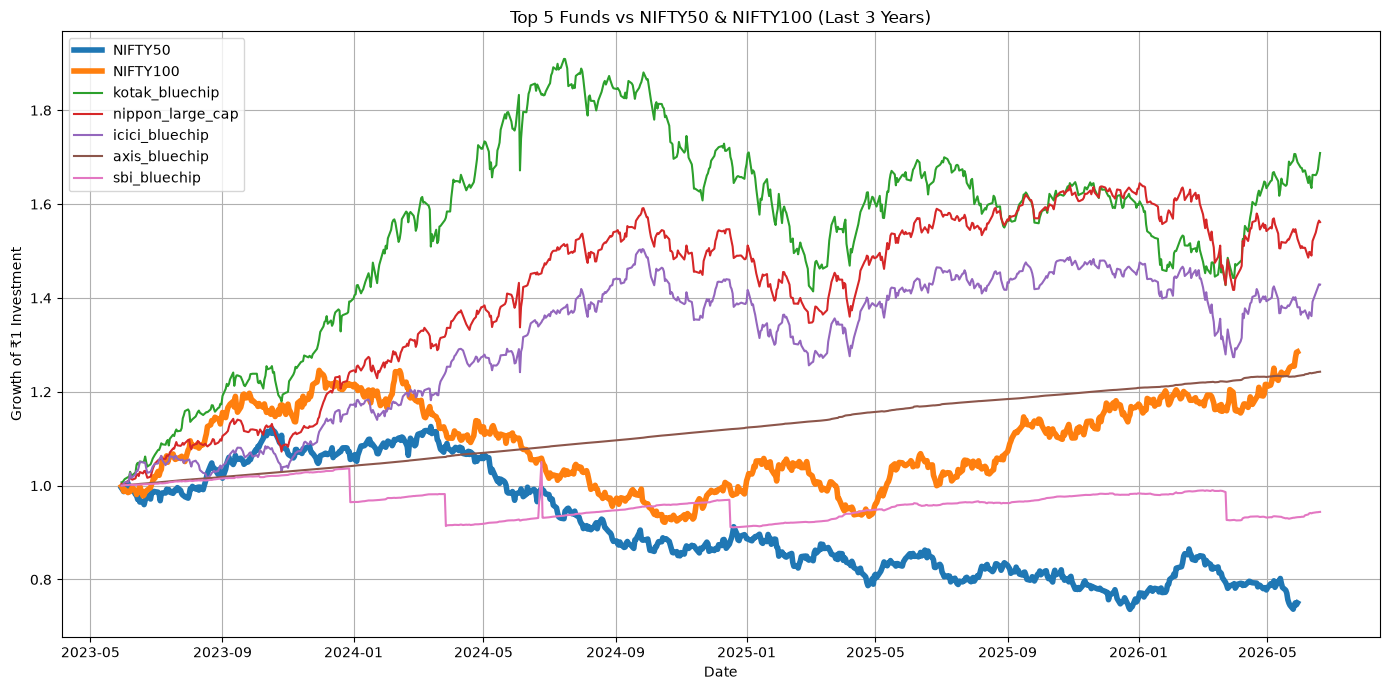

          fund_name  tracking_error_%
0    kotak_bluechip             21.70
1  nippon_large_cap             18.93
2    icici_bluechip             18.74
3     axis_bluechip             12.83
4      sbi_bluechip             17.40

tracking_error.csv saved successfully!


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Benchmark Data
# -----------------------------------

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

# Last 3 Years
end_date = benchmark["date"].max()

start_date = end_date - pd.DateOffset(years=3)

benchmark = benchmark[
    benchmark["date"] >= start_date
]

# -----------------------------------
# NIFTY50
# -----------------------------------

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")

nifty50["return"] = (
    nifty50["close_value"].pct_change()
)

nifty50["growth"] = (
    1 + nifty50["return"]
).cumprod()

# -----------------------------------
# NIFTY100
# -----------------------------------

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["return"] = (
    nifty100["close_value"].pct_change()
)

nifty100["growth"] = (
    1 + nifty100["return"]
).cumprod()

# -----------------------------------
# Plot
# -----------------------------------

plt.figure(figsize=(14,7))

plt.plot(
    nifty50["date"],
    nifty50["growth"],
    label="NIFTY50",
    linewidth=4
)

plt.plot(
    nifty100["date"],
    nifty100["growth"],
    label="NIFTY100",
    linewidth=4
)
# -----------------------------------
# Top 5 Funds
# -----------------------------------

files = [
    "kotak_bluechip_nav.csv",
    "nippon_large_cap_nav.csv",
    "icici_bluechip_nav.csv",
    "axis_bluechip_nav.csv",
    "sbi_bluechip_nav.csv"
]

tracking_results = []

for file in files:

    df = pd.read_csv(
        f"../data/raw/{file}"
    )

    df["date"] = pd.to_datetime(
        df["date"],
        dayfirst=True
    )

    df = df.sort_values("date")

    df = df[df["nav"] > 0]

    df = df[
        df["date"] >= start_date
    ]

    df["fund_return"] = (
        df["nav"].pct_change()
    )

    df["growth"] = (
        1 + df["fund_return"]
    ).cumprod()

    fund_name = file.replace(
        "_nav.csv",
        ""
    )

    plt.plot(
        df["date"],
        df["growth"],
        label=fund_name
    )

    # --------------------------
    # Tracking Error vs NIFTY50
    # --------------------------

    merged = pd.merge(
        df[["date", "fund_return"]],
        nifty50[["date", "return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    tracking_error = (
        np.std(
            merged["fund_return"]
            -
            merged["return"]
        )
        *
        np.sqrt(252)
    )

    tracking_results.append({
        "fund_name":
        fund_name,

        "tracking_error_%":
        round(
            tracking_error * 100,
            2
        )
    })

# -----------------------------------
# Final Chart
# -----------------------------------

plt.title(
    "Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)"
)

plt.xlabel("Date")

plt.ylabel(
    "Growth of ₹1 Investment"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

# -----------------------------------
# Tracking Error Report
# -----------------------------------

tracking_df = pd.DataFrame(
    tracking_results
)

print(tracking_df)

tracking_df.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)

print(
    "\ntracking_error.csv saved successfully!"
)

## day 6

In [3]:
# ==========================================================
# Day 6 - Task 1
# Historical VaR (95%) & CVaR Analysis
# ==========================================================

import pandas as pd
import numpy as np

# ----------------------------------------------------------
# Load fund_name
# ----------------------------------------------------------

nav_df = pd.read_csv("../data/raw/02_nav_history.csv")
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")

# ----------------------------------------------------------
# Convert Date
# ----------------------------------------------------------

nav_df["date"] = pd.to_datetime(nav_df["date"])

# ----------------------------------------------------------
# Merge NAV with Fund Master
# ----------------------------------------------------------

nav_df = nav_df.merge(
    fund_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# ----------------------------------------------------------
# Sort Values
# ----------------------------------------------------------

nav_df = nav_df.sort_values(
    ["scheme_name", "date"]
)

# ----------------------------------------------------------
# Calculate Daily Returns
# ----------------------------------------------------------

nav_df["daily_return"] = (
    nav_df.groupby("scheme_name")["nav"]
          .pct_change()
)

# Remove first-day NaN returns
nav_df = nav_df.dropna(subset=["daily_return"])

# ----------------------------------------------------------
# Calculate VaR & CVaR
# ----------------------------------------------------------

results = []

for fund in nav_df["scheme_name"].unique():

    fund_returns = nav_df.loc[
        nav_df["scheme_name"] == fund,
        "daily_return"
    ]

    # Historical VaR (95%)
    var_95 = np.percentile(fund_returns, 5)

    # Conditional VaR (Expected Shortfall)
    cvar_95 = fund_returns[
        fund_returns <= var_95
    ].mean()

    results.append({
        "scheme name": fund,
        "VaR (95%)": round(var_95 * 100, 2),
        "CVaR (95%)": round(cvar_95 * 100, 2)
    })

# ----------------------------------------------------------
# Create Final Report
# ----------------------------------------------------------

var_cvar_report = pd.DataFrame(results)

# Sort by highest risk
var_cvar_report = var_cvar_report.sort_values(
    "VaR (95%)"
)

# ----------------------------------------------------------
# Display Report
# ----------------------------------------------------------

print("\n===== Historical VaR & CVaR Report =====\n")
print(var_cvar_report)

# ----------------------------------------------------------
# Save CSV
# ----------------------------------------------------------

var_cvar_report.to_csv(
    "var_cvar_report.csv",
    index=False
)

print("\nCSV Saved Successfully!")
print("File Name : var_cvar_report.csv")


===== Historical VaR & CVaR Report =====

                                          scheme name  VaR (95%)  CVaR (95%)
35          SBI Small Cap Fund - Direct Plan - Growth      -2.69       -3.24
6              Axis Small Cap Fund - Regular - Growth      -2.62       -3.17
2              ABSL Small Cap Fund - Regular - Growth      -2.60       -3.25
31     Nippon India Small Cap Fund - Regular - Growth      -2.54       -3.23
36         SBI Small Cap Fund - Regular Plan - Growth      -2.45       -3.06
8               DSP Small Cap Fund - Regular - Growth      -2.35       -3.10
38                UTI Mid Cap Fund - Regular - Growth      -1.92       -2.33
11  HDFC Mid-Cap Opportunities Fund - Regular - Gr...      -1.90       -2.35
18           ICICI Pru Midcap Fund - Regular - Growth      -1.89       -2.43
5                 Axis Midcap Fund - Regular - Growth      -1.85       -2.43
10  HDFC Mid-Cap Opportunities Fund - Direct - Growth      -1.84       -2.31
21      Kotak Emerging Equity Fun